# Exploratory Data Analysis（探索的データ分析）

## 目的
求人充足率低下の要因分析に向けて、求人・応募データの分布、欠損、年次差を確認する。
本Notebookでは、SQLで作成した分析マートをPythonに読み込み、データの品質や分布を確認したうえで、2025年と2026年の傾向を比較する。
この段階では仮説の統計的な有意性を判断せず、データが分析可能な状態になっているか、どのような傾向が見られるかを探索的に確認する。

## 主な確認項目
- 60日以内募集枠充足率
- 選考ファネル
- 給与ギャップ
- スキルギャップ
- 選考リードタイム
- 就業決定率

## 使用する分析マート
- `mart_job_analysis`
  - 1行 = 1求人
  - 求人属性、応募ファネル、就業決定数、60日以内募集枠充足率などを保持

- `mart_application_analysis`
  - 1行 = 1応募案件
  - 給与ギャップ、スキルギャップ、選考リードタイム、辞退・就業決定などを保持

## 1. ライブラリの読み込み
分析に必要なPythonライブラリを読み込む。

- `sqlite3`：SQLiteデータベースへ接続する
- `pandas`：表形式データをDataFrameとして扱う
- `numpy`：数値計算を行う
- `matplotlib`：グラフを作成する

In [1]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. SQLiteデータベースへの接続
Pythonから、合成データおよびSQL分析マートを格納したSQLiteデータベースへ接続する。

Notebookは `notebooks/` フォルダに保存しているため、1階層上の `database/` フォルダを参照する。

In [2]:
conn = sqlite3.connect(
    "../database/recruitment_analytics.sqlite"
)

### 接続先データベースの確認
想定したSQLiteファイルへ接続できていることを確認する。

In [3]:
pd.read_sql_query(
    "PRAGMA database_list;",
    conn
)

,seq,name,file
0,0,main,c:\Users\tomoe\OneDrive\PERSOL\キャリアスカウト\recrui...


## 3. 分析マートの読み込み
SQLで作成した2つの分析マートを、pandasのDataFrameとしてPythonへ読み込む。

- `job_df`：求人単位の分析データ
- `application_df`：応募案件単位の分析データ

SQLでデータの結合・集計を行い、Pythonではその結果を使って探索的データ分析を行う。

In [4]:
job_df = pd.read_sql_query(
    """
    SELECT *
    FROM mart_job_analysis
    """,
    conn
)

application_df = pd.read_sql_query(
    """
    SELECT *
    FROM mart_application_analysis
    """,
    conn
)

## 4. データ件数と内容の確認
読み込んだDataFrameについて、行数・列数と先頭データを確認する。
※SQLiteから想定したデータを正常に読み込めていることを確認する。

In [5]:
print("job_df:", job_df.shape)
print("application_df:", application_df.shape)

job_df: (800, 44)
application_df: (2658, 87)


### 求人マートの先頭行

In [6]:
job_df.head()

,job_id,client_id,ra_id,open_date,close_date,job_status,open_year,open_month,occupation_id,occupation_name,...,visit_count,completed_visit_count,scheduled_visit_count,cancelled_visit_count,placement_count,placement_60d_count,fill_rate_60d,avg_intent_to_recommend_days,avg_recommend_to_schedule_days,avg_intent_to_decision_days
0,JOB00001,CLI013,RA011,2025-10-01,2026-01-22,closed,2025,2025-10,OCC003,コールセンター,...,1,1,0,0,0,0.0,0.000,2.00,5.00,NaN
1,JOB00002,CLI062,RA006,2025-10-19,NaN,open,2025,2025-10,OCC003,コールセンター,...,2,2,0,0,0,0.0,0.000,5.75,4.50,NaN
2,JOB00003,CLI055,RA007,2025-12-19,2026-06-03,closed,2025,2025-12,OCC002,データ入力,...,8,7,0,1,3,1.0,0.333,5.40,5.38,18.67
3,JOB00004,CLI097,RA004,2025-12-25,2026-04-11,closed,2025,2025-12,OCC006,DM（データマネジメント）,...,2,2,0,0,1,1.0,1.000,6.00,4.50,20.00
4,JOB00005,CLI044,RA013,2025-05-29,NaN,open,2025,2025-05,OCC006,DM（データマネジメント）,...,3,3,0,0,1,0.0,0.000,3.67,2.67,10.00


### 応募案件マートの先頭行

In [7]:
application_df.head()

,application_id,job_id,candidate_id,ca_id,application_source,source_entry_id,source_introduction_id,intent_confirmed_date,recommendation_date,recommendation_result,...,placed_flag,decision_date,start_date,agreed_hourly_wage,placement_status,intent_to_decision_days,visit_to_decision_days,open_to_decision_days,job_60d_observed_flag,placed_within_60d_flag
0,APP000785,JOB00001,CAN01670,CA012,ca_introduction,NaN,INT001095,2025-10-06,2025-10-08,accepted,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0
1,APP000965,JOB00002,CAN01057,CA015,ca_introduction,NaN,INT001307,2025-11-13,2025-11-17,accepted,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0
2,APP001060,JOB00002,CAN00600,CA017,self_entry,ENT001158,NaN,2025-12-05,2025-12-11,accepted,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0
3,APP001245,JOB00002,CAN01204,CA016,ca_introduction,NaN,INT001622,2026-01-20,2026-01-27,rejected,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0
4,APP002034,JOB00002,CAN00796,CA021,ca_introduction,NaN,INT002367,2026-06-11,2026-06-17,rejected,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0


## 5. データ型の確認
各列のデータ型と非欠損件数を確認する。
数値として分析したい列が数値型になっているか、想定外の欠損が大量に発生していないかを確認する。

### 求人マート

In [8]:
job_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   job_id                                800 non-null    str    
 1   client_id                             800 non-null    str    
 2   ra_id                                 800 non-null    str    
 3   open_date                             800 non-null    str    
 4   close_date                            501 non-null    str    
 5   job_status                            800 non-null    str    
 6   open_year                             800 non-null    str    
 7   open_month                            800 non-null    str    
 8   occupation_id                         800 non-null    str    
 9   occupation_name                       800 non-null    str    
 10  occupation_group                      800 non-null    str    
 11  location_id                   

### 応募案件マート

In [9]:
application_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 87 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   application_id                       2658 non-null   str    
 1   job_id                               2658 non-null   str    
 2   candidate_id                         2658 non-null   str    
 3   ca_id                                2658 non-null   str    
 4   application_source                   2658 non-null   str    
 5   source_entry_id                      946 non-null    str    
 6   source_introduction_id               1712 non-null   str    
 7   intent_confirmed_date                2658 non-null   str    
 8   recommendation_date                  1823 non-null   str    
 9   recommendation_result                1823 non-null   str    
 10  withdrawal_date                      664 non-null    str    
 11  withdrawal_reason                    664 

## 6. 欠損値の確認
列ごとの欠損値件数を確認する。
欠損が存在すること自体を異常とは判断しない。

例えば、推薦に進んでいない応募案件では `recommendation_date`、辞退していない案件では `withdrawal_date`、就業決定していない案件では `decision_date` がNULLになることは業務上自然である。

ここでは、想定していない列に欠損が発生していないかを確認する。

### 求人マート

In [10]:
job_df.isna().sum()

job_id                                    0
client_id                                 0
ra_id                                     0
open_date                                 0
close_date                              299
job_status                                0
open_year                                 0
open_month                                0
occupation_id                             0
occupation_name                           0
occupation_group                          0
location_id                               0
prefecture_name                           0
area_group                                0
required_slots                            0
offered_hourly_wage                       0
required_skill_level                      0
work_style                                0
job_60d_observed_flag                     0
entry_count                               0
converted_entry_count                     0
application_count                         0
self_entry_application_count    

### 応募案件マート

In [11]:
application_df.isna().sum()

application_id                0
job_id                        0
candidate_id                  0
ca_id                         0
application_source            0
                           ... 
intent_to_decision_days    2259
visit_to_decision_days     2259
open_to_decision_days      2259
job_60d_observed_flag         0
placed_within_60d_flag      209
Length: 87, dtype: int64

### 分析上重要な欠損・観察期間の確認
今回追加した分析項目について、欠損や観察期間の状態を確認する。

特に以下を確認する。
- `fill_rate_60d` のNULLは、60日間観察できていない求人と対応しているか
- `skill_gap` のNULLは、同職種経験がない応募案件と対応しているか
- 30日間観察できていない応募案件がどの程度存在するか

これらのNULLは必ずしもデータ不良ではなく、分析上意味のある欠損として扱う。

In [12]:
print("【求人：60日観察可能フラグ】")
display(
    job_df[
        [
            "job_60d_observed_flag", # open_date + 60日 <= 2026-09-30 の判別フラグ
            "fill_rate_60d", # 60日以内の募集枠充足率
        ]
    ]
    .groupby("job_60d_observed_flag", dropna=False)
    # グループごとの集計
    .agg(
        job_count=("fill_rate_60d", "size"), # NULLを含めて集計
        fill_rate_non_null_count=("fill_rate_60d", "count"), # NULL以外を集計
    )
)

print("\n【応募：同職種経験とskill_gap】")
display(
    application_df[
        [
            "same_occupation_experience_flag", # 同職種経験の有無,1 = NOT NULL
            "skill_gap", # 候補者経験スキルレベル - 必要スキルレベル
        ]
    ]
    .groupby("same_occupation_experience_flag", dropna=False)
    .agg(
        application_count=("skill_gap", "size"), # NULLを含めて集計
        skill_gap_non_null_count=("skill_gap", "count"), # NULL以外を集計
    )
)

print("\n【応募：30日観察可能フラグ】")
display(
    application_df[
        "application_30d_observed_flag"
    ] # 30日間観察可能フラグ,1 = 可能
    .value_counts(dropna=False)
    .sort_index() # インデックス順に並べる
)

【求人：60日観察可能フラグ】


,job_count,fill_rate_non_null_count
job_60d_observed_flag,,
0,99,0
1,701,701



【応募：同職種経験とskill_gap】


,application_count,skill_gap_non_null_count
same_occupation_experience_flag,,
0,563,0
1,2095,2095



【応募：30日観察可能フラグ】


application_30d_observed_flag
0     243
1    2415
Name: count, dtype: int64

## 7. 数値項目の基本統計量
主要な数値項目について、件数・平均・標準偏差・最小値・四分位数・最大値を確認する。

極端な値や業務上不自然な値が含まれていないかを確認する。

### 求人マートの主要数値項目

In [13]:
job_df[
    [
        "required_slots",           # 募集枠数
        "offered_hourly_wage",      # 求人提示時給
        "required_skill_level",     # 必要スキルレベル
        "entry_count",              # 求人サイトからのエントリー総件数
        "application_count",        # 応募案件総数
        "placement_count",          # 最終就業決定数
        "placement_60d_count",      # 求人公開から60日以内の就業決定数
        "job_60d_observed_flag",    # open_date + 60日 <= 2026-09-30 の判別フラグ
        "fill_rate_60d",            # 60日以内の募集枠充足率
    ]
].describe()

,required_slots,offered_hourly_wage,required_skill_level,entry_count,application_count,placement_count,placement_60d_count,job_60d_observed_flag,fill_rate_60d
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,701.000000,800.000000,701.000000
mean,1.758750,2097.625000,2.955000,4.023750,3.322500,0.498750,0.332382,0.876250,0.221225
std,0.863992,634.160515,1.227746,3.040105,3.035212,0.698648,0.577624,0.329502,0.382718
min,1.000000,1200.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1500.000000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,2.000000,2100.000000,3.000000,3.000000,3.000000,0.000000,0.000000,1.000000,0.000000
75%,2.000000,2650.000000,4.000000,6.000000,4.000000,1.000000,1.000000,1.000000,0.333000
max,4.000000,3400.000000,5.000000,17.000000,30.000000,3.000000,3.000000,1.000000,1.000000


### 応募案件マートの主要数値項目

In [14]:
application_df[
    [
        "wage_gap",                         # 給与ギャップ(求人提示時給 - 候補者希望時給)
        "wage_gap_rate",                    # 給与ギャップ率(求人提示時給 - 候補者希望時給)/ 候補者希望時給
        "wage_shortfall_rate",              # 希望額に対する求人提示額の不足率 定義：MAX(希望時給 - 提示時給,0)
        "same_occupation_experience_flag",  # 同職種経験の有無,1 = NOT NULL
        "skill_gap",                        # 候補者経験スキル - 必要スキル
        "intent_to_recommend_days",         # 応募意思確認 → 企業推薦までの日数
        "recommend_to_schedule_days",       # 推薦 → 職場見学設定までの日数
        "schedule_to_visit_days",           # 見学設定 → 実施までの日数
        "intent_to_decision_days",          # 応募意思確認 → 就業決定までの日数
        "screened_out_flag",                # CAスクリーニングで見送りフラグ
        "confirmed_flag",                   # 応募意思確認済み・推薦準備中フラグ
        "withdrawal_flag",                  # 辞退フラグ
        "placed_flag",                      # 就業決定フラグ
        "application_30d_observed_flag",    # 30日間観察可能フラグ(応募意思確認日 + 30日 <= 2026-09-30 の判別フラグ)
    ]
].describe()

,wage_gap,wage_gap_rate,wage_shortfall_rate,same_occupation_experience_flag,skill_gap,intent_to_recommend_days,recommend_to_schedule_days,schedule_to_visit_days,intent_to_decision_days,screened_out_flag,confirmed_flag,withdrawal_flag,placed_flag,application_30d_observed_flag
count,2658.000000,2658.000000,2658.000000,2658.000000,2095.000000,1823.000000,1211.000000,1096.000000,399.000000,2658.000000,2658.000000,2658.000000,2658.000000,2658.000000
mean,-20.673439,0.023449,0.060301,0.788187,-0.083532,4.029073,3.957886,4.535584,15.919799,0.200150,0.014296,0.249812,0.150113,0.908578
std,464.176396,0.248043,0.097781,0.408670,0.676520,2.356468,1.732731,1.698404,4.234173,0.400188,0.118732,0.432985,0.357249,0.288263
min,-2350.000000,-0.642000,0.000000,0.000000,-3.000000,0.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-200.000000,-0.090000,0.000000,1.000000,0.000000,2.000000,3.000000,3.000000,13.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000,4.000000,5.000000,16.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,100.000000,0.069000,0.090000,1.000000,0.000000,6.000000,5.000000,6.000000,19.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,2150.000000,1.792000,0.642000,1.000000,2.000000,8.000000,7.000000,7.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 8. カテゴリ項目の分布確認
職種、勤務形態、応募経路、応募案件ステータスなどについて、カテゴリ別件数を確認する。

特定カテゴリへデータが極端に偏っていないか、想定外のカテゴリ値が存在しないかを確認する。

### 職種別求人件数
 - value_counts：同じ値が何件あるかを数える関数

In [15]:
job_df["occupation_name"].value_counts(
    dropna=False
)

occupation_name
コールセンター          111
一般事務              95
データ入力             88
DM（データマネジメント）     84
品質管理（QC）          84
CRA               81
CRC               77
薬事                71
医薬翻訳              58
統計解析              51
Name: count, dtype: int64

### 勤務形態別求人件数

In [16]:
job_df["work_style"].value_counts(
    dropna=False
)

work_style
onsite    432
hybrid    284
remote     84
Name: count, dtype: int64

### 応募経路別件数

In [17]:
application_df["application_source"].value_counts(
    dropna=False
)

application_source
ca_introduction    1712
self_entry          946
Name: count, dtype: int64

### 応募案件ステータス別件数

In [18]:
application_df["application_status"].value_counts(
    dropna=False
)

application_status
rejected        999
withdrawn       664
screened_out    532
placed          399
confirmed        38
recommended      26
Name: count, dtype: int64

### 辞退ステージ別件数

In [19]:
application_df["withdrawal_stage"].value_counts(
    dropna=False
)

withdrawal_stage
NaN                    1994
pre_recommendation      265
post_recommendation     245
post_visit              154
Name: count, dtype: int64

### スキルマッチ区分別件数

In [20]:
application_df["skill_match_group"].value_counts(
    dropna=False
)

skill_match_group
gap_ge_0           1617
no_same_occ_exp     563
gap_minus1          439
gap_le_minus2        39
Name: count, dtype: int64

### 応募経路別・ステータス別件数

`self_entry` と `ca_introduction` で、選考結果の分布に違いがあるかを確認する。

In [21]:
pd.crosstab(
    application_df["application_source"],
    application_df["application_status"],
    margins=True,
)

application_status,confirmed,placed,recommended,rejected,screened_out,withdrawn,All
application_source,,,,,,,
ca_introduction,8,309,14,756,172,453,1712
self_entry,30,90,12,243,360,211,946
All,38,399,26,999,532,664,2658


## 9. 2025年・2026年の同期間比較
求人公開年および応募年ごとに主要指標を集計し、2025年と2026年の傾向を比較する。
※個別分析に入る前に全体データを俯瞰で見る。

季節差の影響を抑えるため、主比較期間は両年とも**4月〜9月**とする。

この段階では統計的な有意差を判断せず、求人活動量、マッチング状況、選考結果にどのような違いがあるかを探索的に確認する。

### 求人単位の比較
求人件数、募集枠数、エントリー数、応募数、60日以内就業決定数を比較する。

60日以内募集枠充足率は、求人公開後60日間を観察できる求人のみを対象として算出する。
`job_60d_observed_flag = 1`

In [22]:
# 2025年・2026年の4月〜9月を比較対象とする
job_comparison_df = job_df[
    (
        job_df["open_year"].isin(["2025", "2026"])
    )
    & (
        job_df["open_month"].str[5:7].astype(int).between(4, 9)
    )
].copy()


# 求人活動量
job_year_volume = (
    job_comparison_df
    .groupby("open_year")
    .agg(
        job_count=("job_id", "count"),
        total_slots=("required_slots", "sum"),
        total_entries=("entry_count", "sum"),
        total_applications=("application_count", "sum"),
    )
)


# 60日間観察可能な求人
job_60d_observed_df = job_comparison_df[
    job_comparison_df["job_60d_observed_flag"] == 1
].copy()


# 60日以内の充足状況
job_year_60d = (
    job_60d_observed_df
    .groupby("open_year")
    .agg(
        observed_job_count=("job_id", "count"),
        observed_slots=("required_slots", "sum"),
        placements_60d=("placement_60d_count", "sum"),
    )
)


# 集計結果を結合 上記作成したdfをjoin
job_year_summary = (
    job_year_volume
    .join(
        job_year_60d,
        how="left",
    )
)


# 60日以内募集枠充足率(60日以内の就業決定数 ÷ 60日観察可能な求人の募集枠数)
job_year_summary["fill_rate_60d"] = (
    job_year_summary["placements_60d"]
    / job_year_summary["observed_slots"]
)


job_year_summary

,job_count,total_slots,total_entries,total_applications,observed_job_count,observed_slots,placements_60d,fill_rate_60d
open_year,,,,,,,,
2025,243,405,458,1057,243,405,108.0,0.266667
2026,299,544,1875,792,200,366,48.0,0.131148


### 応募案件単位の比較
応募件数、給与ミスマッチ、スキルミスマッチ、推薦までの日数、辞退率、就業決定率を比較する。

給与ミスマッチは `wage_shortfall_rate`、スキルミスマッチは `skill_gap` と同職種経験の有無を確認する。

就業決定率は、応募後30日間を観察できる案件に限定して確認する。

In [23]:
# 2025年・2026年の4月〜9月を比較対象とする
application_comparison_df = application_df[
    (
        application_df["application_year"].isin(["2025", "2026"])
    )
    & (
        application_df["application_month"]
        .str[5:7]
        .astype(int)
        .between(4, 9)
    )
].copy()


# 応募件数・ミスマッチ・選考状況
application_year_volume = (
    application_comparison_df
    .groupby("application_year")
    .agg(
        application_count=(
            "application_id",
            "count",
        ),
        avg_wage_shortfall_rate=(
            "wage_shortfall_rate",              # 希望額に対する求人提示額の不足率 定義：MAX(希望時給 - 提示時給,0)
            "mean",
        ),
        wage_requirement_met_rate=(
            "wage_requirement_met_flag",         # 希望給与を満たしているかフラグ
            "mean",
        ),
        same_occupation_experience_rate=(
            "same_occupation_experience_flag",  # 同職種経験の有無
            "mean",
        ),
        avg_skill_gap=(
            "skill_gap",
            "mean",
        ),
        avg_intent_to_recommend_days=(
            "intent_to_recommend_days",         # 応募意思確認 → 企業推薦までの日数
            "mean",
        ),
        screened_out_rate=(
            "screened_out_flag",                # CAスクリーニングで見送りフラグ
            "mean",
        ),
        withdrawal_rate=(
            "withdrawal_flag",                  # 辞退フラグ
            "mean",
        ),
        process_withdrawal_rate=(
            "process_withdrawal_flag",          # 他案件の就業決定で並行終了した応募案件を除くフラグ
            "mean",
        ),
    )
)


# 30日間観察可能な応募案件
application_30d_observed_df = application_comparison_df[
    application_comparison_df["application_30d_observed_flag"] == 1
].copy()


# 30日以内就業決定フラグ
application_30d_observed_df["placed_within_30d_flag"] = (
    (
        application_30d_observed_df["placed_flag"].eq(1)                # eq(1)とは、== 1と同様
    )
    & (
        application_30d_observed_df["intent_to_decision_days"].le(30)   # le(30)とは、<= 30と同様
    )
).astype(int)


# 30日間観察可能案件の成果指標
application_year_outcome = (
    application_30d_observed_df
    .groupby("application_year")
    .agg(
        observed_application_count=(
            "application_id",
            "count",
        ),
        placement_30d_rate=(
            "placed_within_30d_flag",
            "mean",
        ),
    )
)


# 集計結果を結合
application_year_summary = (
    application_year_volume
    .join(
        application_year_outcome,
        how="left",
    )
)


application_year_summary

,application_count,avg_wage_shortfall_rate,wage_requirement_met_rate,same_occupation_experience_rate,avg_skill_gap,avg_intent_to_recommend_days,screened_out_rate,withdrawal_rate,process_withdrawal_rate,observed_application_count,placement_30d_rate
application_year,,,,,,,,,,,
2025,702,0.047061,0.545584,0.886040,-0.038585,1.487455,0.160969,0.202279,0.156695,702,0.198006
2026,1162,0.067371,0.494836,0.719449,-0.177033,5.995640,0.239243,0.280551,0.248709,919,0.132753


## 10. 60日以内募集枠充足率の年次比較
主要KPIである60日以内募集枠充足率を、2025年と2026年で比較する。

比較対象は9章と同様に4月〜9月とし、求人公開後60日間を観察できた求人のみを対象とする。

ここでは年次差の大きさと方向を確認し、統計的な有意差の判断は行わない。

open_year
2025    26.666667
2026    13.114754
Name: fill_rate_60d, dtype: float64


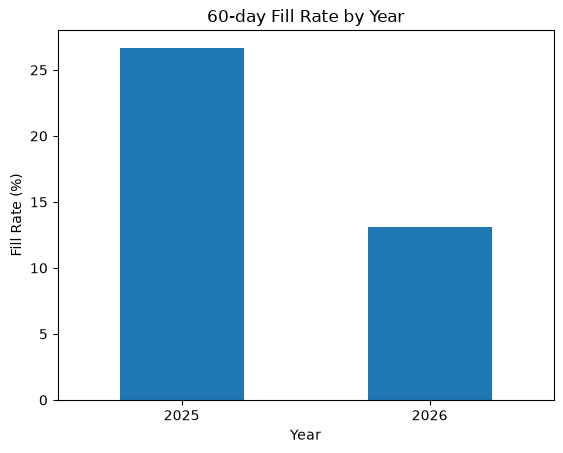

In [24]:
# 割合を%へ変換
fill_rate_plot = job_year_summary["fill_rate_60d"] * 100

print(fill_rate_plot)

# "fill_rate_plot"を棒グラフとして描画する
fill_rate_plot.plot(kind="bar")

plt.title("60-day Fill Rate by Year")
plt.xlabel("Year")
plt.ylabel("Fill Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 11. 選考ファネルの年次比較
応募から推薦、推薦から職場見学、職場見学から就業決定までの各工程について、2025年と2026年の転換率を比較する。

In [25]:
# 2025年・2026年の4月〜8月、30日間観察可能な応募案件
funnel_df = application_30d_observed_df[
    application_30d_observed_df["application_month"]
    .str[5:7]
    .astype(int)
    .between(4, 8)
].copy()

In [26]:
funnel_summary = (
    funnel_df
    .groupby("application_year")
    .agg(
        application_count=("application_id", "count"),
        recommendation_rate=("recommended_flag", "mean"),
        visit_rate=("visit_completed_flag", "mean"),
        placement_rate=("placed_within_30d_flag", "mean"),
    )
)

funnel_summary

,application_count,recommendation_rate,visit_rate,placement_rate
application_year,,,,
2025,558,0.788530,0.519713,0.188172
2026,919,0.648531,0.378672,0.132753


In [27]:
stage_conversion = pd.DataFrame(
    index=funnel_summary.index
)

# 応募 → 推薦
stage_conversion["application_to_recommendation"] = (
    funnel_summary["recommendation_rate"]
)

# 推薦 → 職場見学
stage_conversion["recommendation_to_visit"] = (
    funnel_summary["visit_rate"]
    / funnel_summary["recommendation_rate"]
)

# 職場見学 → 就業決定
stage_conversion["visit_to_placement"] = (
    funnel_summary["placement_rate"]
    / funnel_summary["visit_rate"]
)

# %表示用
stage_conversion = stage_conversion * 100

In [28]:
stage_conversion_change = pd.DataFrame({
    "2025": stage_conversion.loc["2025"],
    "2026": stage_conversion.loc["2026"],
})

stage_conversion_change["change_pt"] = (
    stage_conversion_change["2026"]
    - stage_conversion_change["2025"]
)

stage_conversion_change.round(1)

,2025,2026,change_pt
application_to_recommendation,78.9,64.9,-14.0
recommendation_to_visit,65.9,58.4,-7.5
visit_to_placement,36.2,35.1,-1.1


## 12. 給与不足率の年次比較
候補者の希望時給に対して、求人提示時給がどの程度不足しているかを2025年と2026年で比較する。

`wage_shortfall_rate` は、
`max((希望時給 - 提示時給) ÷ 希望時給, 0)`

として算出し、提示時給が希望時給以上の場合は0となる。

比較対象は9章と同様に4月〜9月とし、給与ミスマッチの分布にどのような違いがあるかを確認する。

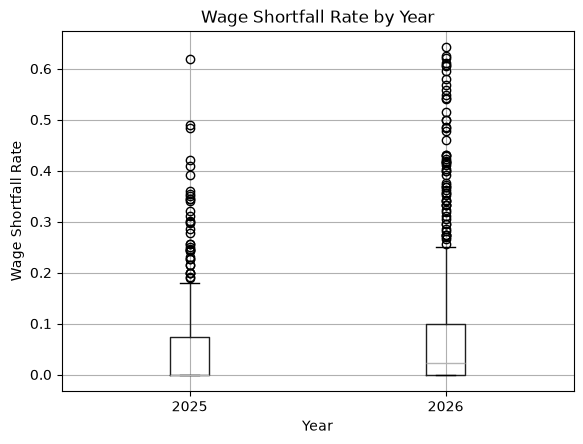

In [29]:
# 9章で作成したdfのcolumnを使用した箱ひげ図を描画する
application_comparison_df.boxplot(
    column="wage_shortfall_rate",
    by="application_year"
)

plt.title("Wage Shortfall Rate by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Wage Shortfall Rate")

plt.show()

## 13. スキルミスマッチの年次比較

スキルミスマッチは、以下の2つに分けて確認する。
1. 求人と同じ職種の経験があるか
2. 同職種経験がある場合、候補者スキルレベルが求人要求スキルレベルをどの程度満たしているか

`same_occupation_experience_flag` は同職種経験の有無を表す。

`skill_gap` は、
`候補者スキルレベル - 求人要求スキルレベル`
として算出し、同職種経験がない場合はNULLとする。

比較対象は9章と同様に4月〜9月とし、2025年と2026年でスキルミスマッチの分布にどのような違いがあるかを確認する。

In [30]:
# 対象データを選定する(フラグ列のみ対象)
experience_rate_by_year = (
    application_comparison_df
    .groupby("application_year")["same_occupation_experience_flag"]
    .mean()
    * 100
)

# 求人と同じ職種の経験割合
experience_rate_by_year.map(
    lambda x: f"{x:.1f}%"
)

application_year
2025    88.6%
2026    71.9%
Name: same_occupation_experience_flag, dtype: str

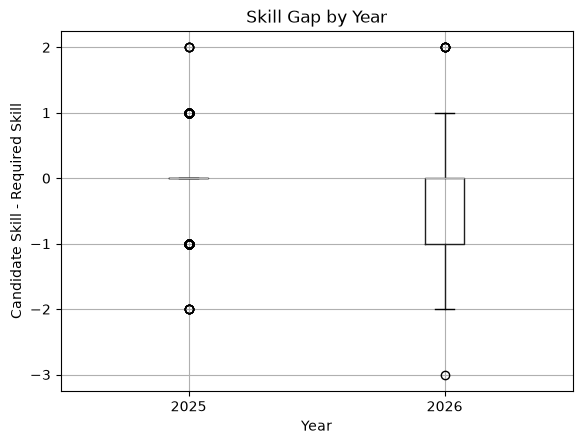

,count,mean_skill_gap,median_skill_gap
application_year,,,
2025,622,-0.04,0.0
2026,836,-0.18,0.0


In [31]:
# 箱ひげ図で比較したい数値列を指定
# ※"skill_gap"のNULLは自動的に除外されるため、同一職種のみの比較になる
application_comparison_df.boxplot(
    column="skill_gap",
    by="application_year"
)


plt.title("Skill Gap by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Candidate Skill - Required Skill")

plt.show()

# 箱ひげ図の件数・平均値・中央値を表示
skill_gap_summary = (
    application_comparison_df
    .groupby("application_year")
    .agg(
        count=("skill_gap", "count"),
        mean_skill_gap=("skill_gap", "mean"),
        median_skill_gap=("skill_gap", "median"),
    )
    .round(2)
)

skill_gap_summary


## 14. 応募意思確認から推薦までの日数の年次比較
応募意思を確認してから企業推薦までに要した日数を、2025年と2026年で比較する。

`intent_to_recommend_days` が長いほど、応募意思確認後の推薦プロセスに時間を要していることを示す。
この指標は推薦日が存在する応募案件のみで算出されるため、推薦まで進んだ案件を対象とした比較となる。

比較対象は9章と同様に4月〜9月とし、推薦までのリードタイム分布にどのような違いがあるかを確認する。

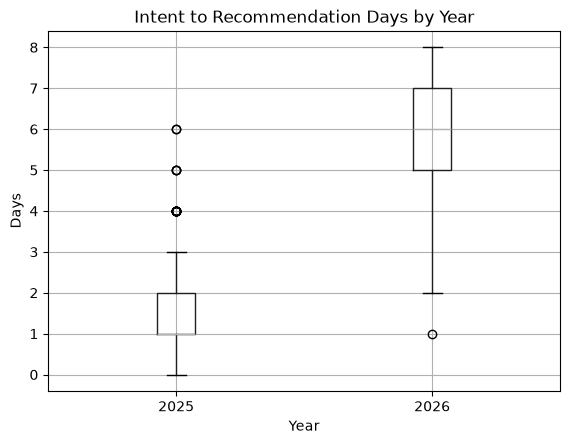

,count,mean_days,median_days
application_year,,,
2025,558,1.5,1.0
2026,688,6.0,6.0


In [32]:
# 箱ひげ図を表示
application_comparison_df.boxplot(
    column="intent_to_recommend_days",
    by="application_year"
)

plt.title("Intent to Recommendation Days by Year") # 年別の応募意思確認から推薦までの日数
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Days")

plt.show()

# 箱ひげ図の件数・平均値・中央値を表示
recommend_days_summary = (
    application_comparison_df
    .groupby("application_year")
    .agg(
        count=("intent_to_recommend_days", "count"),
        mean_days=("intent_to_recommend_days", "mean"),
        median_days=("intent_to_recommend_days", "median"),
    )
    .round(1)
)

recommend_days_summary

## 15. 30日以内就業決定率の年次比較
応募意思確認後30日以内に就業決定へ至った割合を、2025年と2026年で比較する。

就業決定率は、給与条件、スキル適合度、選考リードタイムなど複数要因の影響を受ける最終成果指標の一つとして確認する。
30日間の観察期間を両年でそろえるため、比較対象は2025年・2026年ともに4月〜8月の応募案件とする。

ここでは年次差の大きさと方向を確認し、要因の検証は後続の仮説分析で行う。

application_year
2025    18.817204
2026    13.275299
Name: placed_within_30d_flag, dtype: float64


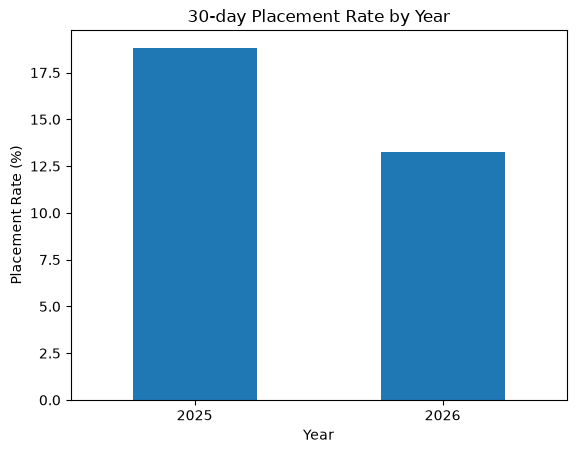

In [33]:
# 30日間の観察が可能な同期間（4月〜8月）を比較
placement_comparison_df = application_df[
    (application_df["application_year"].isin(["2025", "2026"]))
    & (application_df["application_month"].str[5:7].astype(int).between(4, 8))
    & (application_df["application_30d_observed_flag"] == 1)
].copy()


# 応募意思確認後30日以内の就業決定フラグ
placement_comparison_df["placed_within_30d_flag"] = (
    (placement_comparison_df["placed_flag"] == 1)
    & (placement_comparison_df["intent_to_decision_days"] <= 30)
).astype(int)


# 年別の30日以内就業決定率
placement_rate_by_year = (
    placement_comparison_df.groupby("application_year")["placed_within_30d_flag"].mean() * 100
)

# 年別の30日以内就業決定率を表示
print(placement_rate_by_year)

# 棒グラフを表示
placement_rate_by_year.plot(kind="bar")

plt.title("30-day Placement Rate by Year") # 年別30日以内就業決定率
plt.xlabel("Year")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 16. EDA所感

### 1. 2026年は求人充足率が大きく悪化している

60日以内募集枠充足率は、2025年の26.7%から2026年は13.1%へ低下した。
また、30日以内就業決定率も18.8%から13.3%へ低下しており、
2026年は前年と比較して求人充足・就業決定ともに悪化していることを確認した。

### 2. 特に選考前半の転換率が悪化している

選考ファネルを確認すると、
- 応募 → 推薦：78.9% → 64.9%（-14.0pt）
- 推薦 → 職場見学：65.9% → 58.4%（-7.5pt）
- 職場見学 → 就業決定：36.2% → 35.1%（-1.1pt）
となっており、最も大きく低下しているのは「応募 → 推薦」であった。

一方、「職場見学 → 就業決定」の転換率には大きな年次差が見られない。

このことから、2026年の充足率低下は、職場見学後に就業決定しにくくなったことよりも、
応募から推薦・職場見学へ進むまでの選考前半で候補者が減少していることの影響が大きい可能性がある。

### 3. 選考前半の悪化に関連しそうな変化が見られる

応募者と求人条件を確認すると、2026年は給与不足率が上昇し、
同職種経験率も88.6%から71.9%へ低下している。

スキルギャップについても不足方向への変化が見られることから、
求人要件と応募者の経験・スキル・給与条件のミスマッチが拡大している可能性がある。

また、応募意思確認から推薦までの日数は、
2025年の平均が1.5日から2026年は6.0日へ伸長しており、
選考リードタイムについても大きな変化が確認された。

### 4. 次の分析方針

以上から、2026年の求人充足率低下については、選考前半の転換率低下が重要な分析ポイントと考える。

次工程では、その背景要因として、
- スキル・経験のミスマッチ
- 給与条件のミスマッチ
- 応募から推薦までのリードタイム長期化
に着目し、推薦率や辞退率との関係を検証する。

これにより、「どの要因が応募 → 推薦の転換率低下に関係しているのか」を明らかにし、求人充足率低下の要因を絞り込む。